
[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
# Analyse de Stratégie Corporate : STMicroelectronics
## Overview
STMicroelectronics (ST) est un acteur majeur des semi-conducteurs, exposé à l’automobile, l’industriel et l’électronique.
Ce notebook propose :
- Un aperçu financier (cours + revenus)
- Une prévision de revenus (pessimiste / neutre / optimiste)
- Porter Five Forces, SWOT (wordcloud) et recommandations


✅ Cours récupéré via : STM


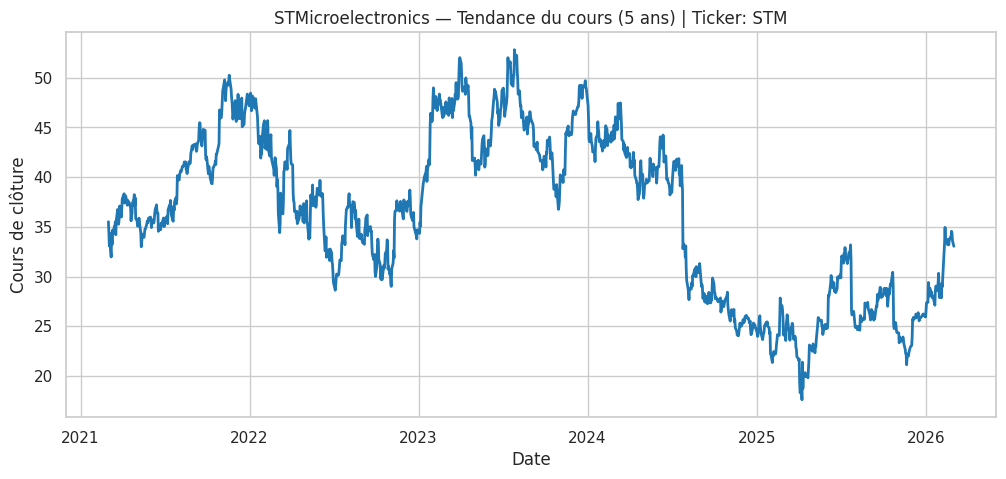

In [22]:
# =========================
# BLOC 1/3 — Setup + Intro + Stock Trend
# =========================

!pip -q install yfinance wordcloud seaborn

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_theme(style="whitegrid")

print("# Analyse de Stratégie Corporate : STMicroelectronics")
print("## Overview")
print("STMicroelectronics (ST) est un acteur majeur des semi-conducteurs, exposé à l’automobile, l’industriel et l’électronique.")
print("Ce notebook propose :")
print("- Un aperçu financier (cours + revenus)")
print("- Une prévision de revenus (pessimiste / neutre / optimiste)")
print("- Porter Five Forces, SWOT (wordcloud) et recommandations")
print("\n")

# --- Données boursières (yfinance) ---
tickers_to_try = ["STM", "STM.PA"]
hist = None
used_ticker = None

for tkr in tickers_to_try:
    try:
        tk = yf.Ticker(tkr)
        tmp = tk.history(period="5y")
        if tmp is not None and not tmp.empty:
            hist = tmp.copy()
            used_ticker = tkr
            break
    except Exception:
        pass

if hist is None or hist.empty:
    print("⚠️ Yahoo Finance ne renvoie pas le cours. On utilise des données proxy (simulées).")
    dates = pd.date_range(start="2019-01-01", periods=60, freq="ME")
    prices = np.linspace(25, 55, 60) + np.random.normal(0, 3, 60)
    hist = pd.DataFrame({"Close": prices}, index=dates)
    used_ticker = "PROXY"
else:
    print(f"✅ Cours récupéré via : {used_ticker}")

plt.figure(figsize=(12,5))
sns.lineplot(data=hist, x=hist.index, y="Close", linewidth=2, color="#1f77b4")
plt.title(f"STMicroelectronics — Tendance du cours (5 ans) | Ticker: {used_ticker}")
plt.xlabel("Date")
plt.ylabel("Cours de clôture")
plt.show()

## Financial Analysis — Revenus (yfinance si possible)
✅ Revenus récupérés via : STM


,Année,Revenus
0,2021,1.276100e+10
1,2022,1.612800e+10
2,2023,1.728600e+10
3,2024,1.326900e+10



## Hypothèses de croissance
- Source : STM
- CAGR estimé : 1.31%
- Pessimiste : 0.79% | Neutre : 1.31% | Optimiste : 1.83%


,Année,Pessimiste,Neutre,Optimiste
0,2025,1.337327e+10,1.344279e+10,1.351230e+10
1,2026,1.347837e+10,1.361885e+10,1.376007e+10
2,2027,1.358428e+10,1.379722e+10,1.401238e+10
3,2028,1.369103e+10,1.397793e+10,1.426931e+10
4,2029,1.379862e+10,1.416100e+10,1.453096e+10


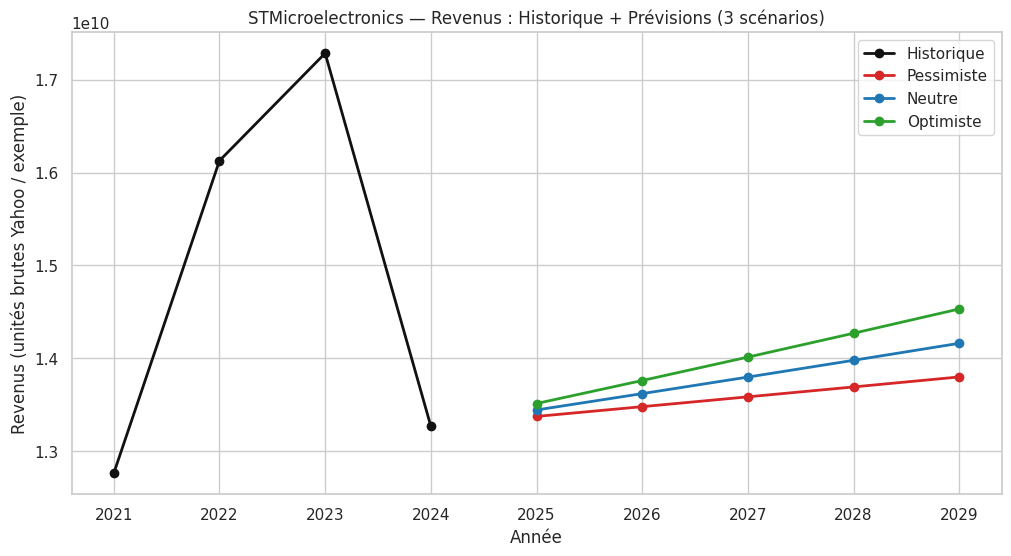

In [23]:
# =========================
# BLOC 2/3 — Revenus + Prévisions (3 scénarios)
# =========================

def get_revenue_history_from_yfinance(ticker_symbol: str):
    t = yf.Ticker(ticker_symbol)

    # Méthode A : income_stmt
    try:
        inc = getattr(t, "income_stmt", None)

        if inc is not None and isinstance(inc, pd.DataFrame) and not inc.empty:
            candidates = [
                x for x in inc.index
                if str(x).lower() in ["total revenue", "totalrevenue", "revenuetotal"]
            ]
            if len(candidates) == 0:
                candidates = [x for x in inc.index if "revenue" in str(x).lower()]

            if len(candidates) > 0:
                rev = inc.loc[candidates[0]].copy()
                rev.index = pd.to_datetime(rev.index)
                rev = rev.sort_index()
                rev = rev[~rev.index.isna()]

                rev_series = pd.Series(rev.values, index=rev.index.year, name="Revenue")
                rev_series = rev_series[rev_series > 0].dropna()
                return rev_series

    except Exception:
        pass

    # Méthode B : financials
    try:
        fin = t.financials
        if fin is not None and isinstance(fin, pd.DataFrame) and not fin.empty:
            candidates = [x for x in fin.index if str(x).lower() in ["total revenue", "totalrevenue"]]
            if len(candidates) == 0:
                candidates = [x for x in fin.index if "revenue" in str(x).lower()]

            if len(candidates) > 0:
                rev = fin.loc[candidates[0]].copy()
                rev.index = pd.to_datetime(rev.index)
                rev = rev.sort_index()

                rev_series = pd.Series(rev.values, index=rev.index.year, name="Revenue")
                rev_series = rev_series[rev_series > 0].dropna()
                return rev_series

    except Exception:
        pass

    return None


print("## Financial Analysis — Revenus (yfinance si possible)")
rev_hist = None
rev_ticker_used = None

for tkr in ["STM", "STM.PA"]:
    s = get_revenue_history_from_yfinance(tkr)
    if s is not None and len(s) >= 3:
        rev_hist = s.copy()
        rev_ticker_used = tkr
        break

if rev_hist is None:
    print("⚠️ Revenus non disponibles via yfinance. On utilise un exemple (à remplacer par tes chiffres officiels).")
    rev_hist = pd.Series(
        data=[9500, 10700, 12200, 16100, 17100, 13800],  # EXEMPLE
        index=[2019, 2020, 2021, 2022, 2023, 2024],
        name="Revenue"
    )
    rev_ticker_used = "EXEMPLE"
else:
    print(f"✅ Revenus récupérés via : {rev_ticker_used}")

df_rev = pd.DataFrame({"Année": rev_hist.index, "Revenus": rev_hist.values}).sort_values("Année")
display(df_rev)

# --- Prévisions 3 scénarios ---
years_forward = 5
last_year = int(rev_hist.index.max())
first_year = int(rev_hist.index.min())

last_revenue = float(rev_hist.loc[last_year])
first_revenue = float(rev_hist.loc[first_year])

n_years = last_year - first_year
cagr = 0.05 if (n_years <= 0 or first_revenue <= 0) else (last_revenue / first_revenue) ** (1 / n_years) - 1

pess_growth = max(-0.05, 0.60 * cagr)
base_growth = cagr
opt_growth  = min(0.25, 1.40 * cagr)

future_years = list(range(last_year + 1, last_year + years_forward + 1))

def project_revenue(start_value, growth, years):
    v = start_value
    out = []
    for _ in years:
        v = v * (1 + growth)
        out.append(v)
    return np.array(out)

proj = pd.DataFrame({
    "Année": future_years,
    "Pessimiste": project_revenue(last_revenue, pess_growth, future_years),
    "Neutre": project_revenue(last_revenue, base_growth, future_years),
    "Optimiste": project_revenue(last_revenue, opt_growth, future_years)
})

print("\n## Hypothèses de croissance")
print(f"- Source : {rev_ticker_used}")
print(f"- CAGR estimé : {cagr:.2%}")
print(f"- Pessimiste : {pess_growth:.2%} | Neutre : {base_growth:.2%} | Optimiste : {opt_growth:.2%}")

display(proj)

plt.figure(figsize=(12,6))
plt.plot(rev_hist.index, rev_hist.values, marker="o", linewidth=2, label="Historique", color="#111111")
plt.plot(proj["Année"], proj["Pessimiste"], marker="o", linewidth=2, label="Pessimiste", color="#d62728")
plt.plot(proj["Année"], proj["Neutre"],     marker="o", linewidth=2, label="Neutre",     color="#1f77b4")
plt.plot(proj["Année"], proj["Optimiste"],  marker="o", linewidth=2, label="Optimiste",  color="#2ca02c")
plt.title("STMicroelectronics — Revenus : Historique + Prévisions (3 scénarios)")
plt.xlabel("Année")
plt.ylabel("Revenus (unités brutes Yahoo / exemple)")
plt.legend()
plt.show()

## Competitive Analysis — Porter’s Five Forces


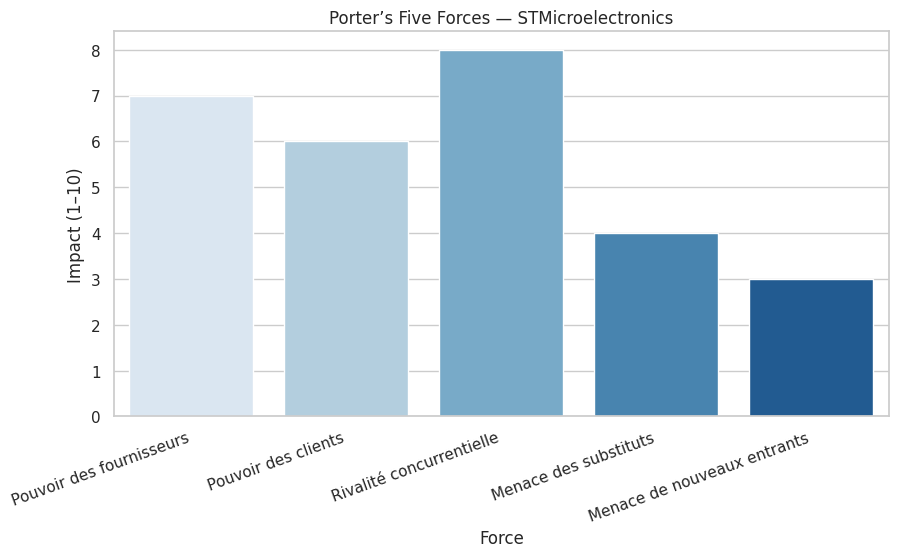

## SWOT Analysis — Word Cloud


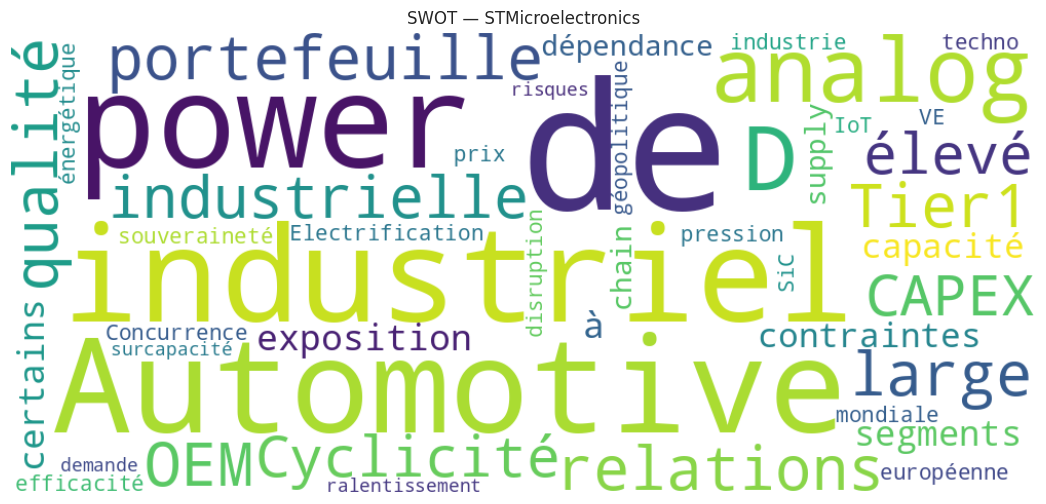

## Strategic Recommendations
- 1) Prioriser les segments à forte valeur : auto, industriel, power/analog (éviter les commodités quand possible).
- 2) Accélérer la feuille de route SiC : capacité, rendements, partenariats et contrats long terme.
- 3) Renforcer la résilience supply chain : dual-sourcing, diversification, scénarios de continuité.
- 4) Discipline CAPEX : phaser les investissements selon le cycle et piloter le ROIC.
- 5) Différenciation go-to-market : co-développement avec OEM/Tier1 + solutions (hardware + software + support).
- 6) Souveraineté/ESG : aligner projets industriels et financement public, et clarifier la création de valeur.

✅ Export CSV : stm_revenue_forecast_3_scenarios.csv


In [24]:
# =========================
# BLOC 3/3 — Porter + SWOT + Recommandations
# =========================

print("## Competitive Analysis — Porter’s Five Forces")

forces = {
    "Pouvoir des fournisseurs": 7,
    "Pouvoir des clients": 6,
    "Rivalité concurrentielle": 8,
    "Menace des substituts": 4,
    "Menace de nouveaux entrants": 3
}

df_forces = pd.DataFrame({"Force": list(forces.keys()), "Score": list(forces.values())})

plt.figure(figsize=(10,5))
sns.barplot(data=df_forces, x="Force", y="Score", hue="Force", dodge=False, palette="Blues", legend=False)
plt.title("Porter’s Five Forces — STMicroelectronics")
plt.ylabel("Impact (1–10)")
plt.xticks(rotation=20, ha="right")
plt.show()

print("## SWOT Analysis — Word Cloud")

swot = {
    "Strengths": "Automotive & industriel, power & analog, R&D, portefeuille large, relations OEM/Tier1, qualité industrielle",
    "Weaknesses": "Cyclicité, CAPEX élevé, exposition à certains segments, contraintes de capacité, dépendance supply chain",
    "Opportunities": "Electrification/VE, SiC, industrie 4.0, IoT, souveraineté européenne, efficacité énergétique",
    "Threats": "Concurrence mondiale, pression prix, géopolitique, disruption techno, ralentissement demande, risques de surcapacité"
}

wordcloud = WordCloud(width=1000, height=450, background_color="white").generate(" ".join(swot.values()))
plt.figure(figsize=(14,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("SWOT — STMicroelectronics")
plt.show()

print("## Strategic Recommendations")
recommendations = [
    "1) Prioriser les segments à forte valeur : auto, industriel, power/analog (éviter les commodités quand possible).",
    "2) Accélérer la feuille de route SiC : capacité, rendements, partenariats et contrats long terme.",
    "3) Renforcer la résilience supply chain : dual-sourcing, diversification, scénarios de continuité.",
    "4) Discipline CAPEX : phaser les investissements selon le cycle et piloter le ROIC.",
    "5) Différenciation go-to-market : co-développement avec OEM/Tier1 + solutions (hardware + software + support).",
    "6) Souveraineté/ESG : aligner projets industriels et financement public, et clarifier la création de valeur."
]

for r in recommendations:
    print(f"- {r}")

# Export
proj.to_csv("stm_revenue_forecast_3_scenarios.csv", index=False)
print("\n✅ Export CSV : stm_revenue_forecast_3_scenarios.csv")